# 06: ElasticNet Regression Training


## Chapter 4: Model Development

This notebook trains an ElasticNet regression model using the same features/config and chronological split as the earlier models.


In [15]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 200)


In [16]:
# Load feature definitions from Notebook 01 output
CONFIG_PATH = Path("../data/processed/modeling_config.json")
cfg = json.loads(CONFIG_PATH.read_text(encoding="utf-8"))
data_csv = Path(cfg["data_csv"])
df = pd.read_csv(data_csv, index_col=0, parse_dates=True)
feature_cols = cfg["feature_cols"]
target_col = cfg["target_col"]

df.head()


,Adj Close,adj_close_smooth,target_ret_1d_pct,volume,rsi_14,macd_hist_12_26_9,adx_14,atr_14,obv,sma_10,ema_20,bb_bandwidth_20_2,target_close_1d
Date,,,,,,,,,,,,,
2016-05-31,22.754038,22.340601,-1.401967,1.670290e+08,49.327530,0.364617,75.439719,2.375693,-1.812087e+09,21.699815,22.196014,7.108358,22.435034
2016-06-01,22.435034,22.359487,-0.751555,1.569618e+08,49.876780,0.358149,70.590680,2.372857,-1.655125e+09,21.812270,22.211583,7.094068,22.266422
2016-06-02,22.266422,22.340874,0.204634,1.577228e+08,49.309527,0.342375,66.200984,2.365781,-1.812848e+09,21.916635,22.223897,7.327383,22.311987
2016-06-03,22.311987,22.335097,0.725087,1.489821e+08,49.122774,0.321636,62.124837,2.359600,-1.961830e+09,22.017079,22.234487,7.684564,22.473768
2016-06-06,22.473768,22.362831,0.405594,1.378197e+08,50.099791,0.300276,57.830825,2.366450,-1.824010e+09,22.112974,22.246710,8.098510,22.564920


In [17]:
# Train/test split (chronological) — same approach as Notebook 03
split_idx = int(len(df) * 0.9)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_test = test_df[feature_cols]
y_test = test_df[target_col]

print("Configured target:", target_col)
print("Configured features:", feature_cols)
print(f"Train rows: {len(train_df)}")
print(f"Test rows:  {len(test_df)}")
print(f"Train period: {train_df.index.min().date()} -> {train_df.index.max().date()}")
print(f"Test period:  {test_df.index.min().date()} -> {test_df.index.max().date()}")


Configured target: target_close_1d
Configured features: ['rsi_14', 'macd_hist_12_26_9', 'bb_bandwidth_20_2', 'adx_14', 'obv', 'adj_close_smooth', 'ema_20', 'atr_14', 'volume']
Train rows: 2232
Test rows:  248
Train period: 2016-05-31 -> 2025-04-14
Test period:  2025-04-15 -> 2026-04-10


In [18]:
def regression_metrics(y_true, y_pred, model_name: str) -> pd.DataFrame:
    metrics = {
        "Model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }
    return pd.DataFrame([metrics]).round(4)


In [19]:
# Primary model: ElasticNet (with standardization)
enet_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("enet", ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42)),
    ]
)

enet_model.fit(X_train, y_train)
enet_pred_train = enet_model.predict(X_train)
enet_pred_test = enet_model.predict(X_test)

print(regression_metrics(y_train, enet_pred_train, "ElasticNet (train)"))
print(regression_metrics(y_test, enet_pred_test, "ElasticNet (test)"))


                Model      MAE     RMSE    MAPE      R2
0  ElasticNet (train)  10.0324  12.7158  0.1319  0.9633
               Model      MAE     RMSE    MAPE     R2
0  ElasticNet (test)  29.5026  32.4315  0.1182 -0.361


In [20]:
# Hyperparameter tuning with TimeSeriesSplit
# - alpha controls overall regularization strength
# - l1_ratio mixes L1 (Lasso) and L2 (Ridge): 0=Ridge, 1=Lasso
param_grid = {
    "enet__alpha": np.logspace(-5, 1, 7),
    "enet__l1_ratio": [0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.85, 0.9, 0.95, 0.99],
}

grid = GridSearchCV(
    estimator=enet_model,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=TimeSeriesSplit(n_splits=5),
    n_jobs=-1,
    verbose=1,
)

grid.fit(X_train, y_train)
print("Best CV RMSE:", -grid.best_score_)
grid.best_params_


Fitting 5 folds for each of 70 candidates, totalling 350 fits
Best CV RMSE: 3.3952010385953706


C:\Users\yeapz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.199e+04, tolerance: 9.846e+02
  model = cd_fast.enet_coordinate_descent(


{'enet__alpha': np.float64(1e-05), 'enet__l1_ratio': 0.99}

In [21]:
# Final tuned model ? evaluate on the held-out test period
best_enet_pipe = grid.best_estimator_
best_pred_test = best_enet_pipe.predict(X_test)

print(regression_metrics(y_test, best_pred_test, "ElasticNet (tuned)"))


                Model     MAE    RMSE    MAPE      R2
0  ElasticNet (tuned)  4.3075  5.6781  0.0181  0.9583


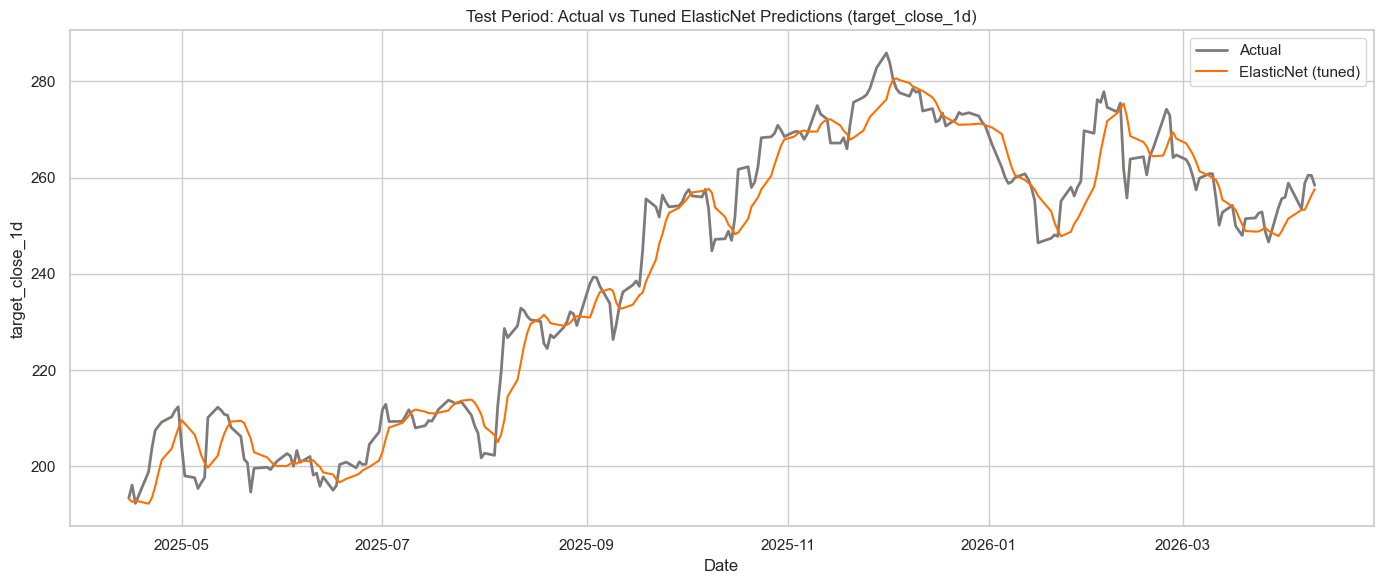

In [22]:
# Plot: Actual vs tuned model predictions
pred_df = pd.DataFrame(index=y_test.index)
pred_df["Actual"] = y_test
pred_df["ElasticNet_Tuned"] = best_pred_test

plt.figure(figsize=(14, 6))
plt.plot(pred_df.index, pred_df["Actual"], label="Actual", linewidth=2, color="#7E7A7A")
plt.plot(pred_df.index, pred_df["ElasticNet_Tuned"], label="ElasticNet (tuned)", color="#FF6F00")
plt.title(f"Test Period: Actual vs Tuned ElasticNet Predictions ({target_col})")
plt.xlabel("Date")
plt.ylabel(target_col)
plt.legend()
plt.tight_layout()
plt.show()


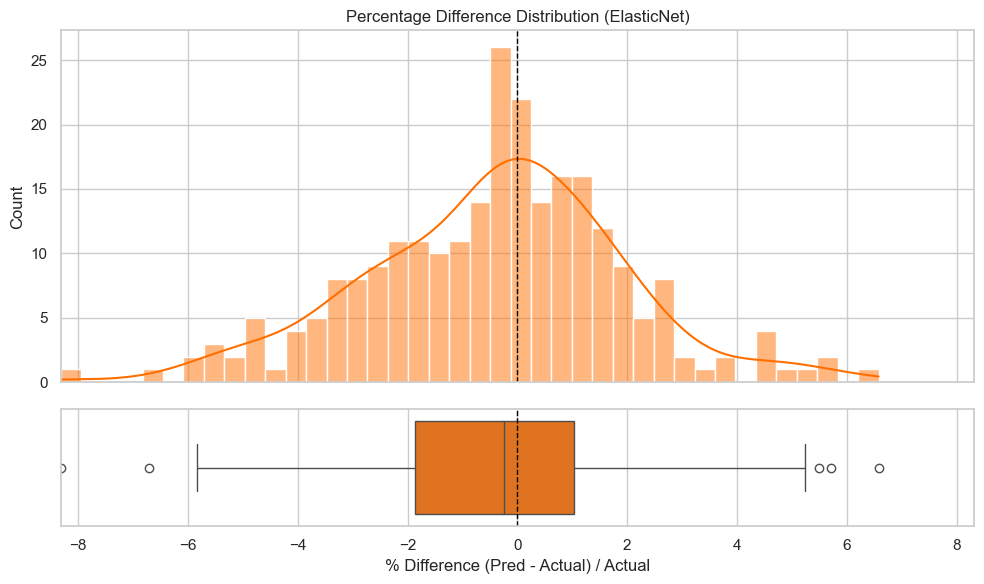

In [23]:
y_test_arr = np.asarray(y_test)
best_pred_arr = np.asarray(best_pred_test)
pct_diff = np.where(y_test_arr != 0, ((best_pred_arr - y_test_arr) / y_test_arr) * 100, np.nan)

valid_pct_diff = pct_diff[~np.isnan(pct_diff)]
if valid_pct_diff.size == 0:
    valid_pct_diff = np.array([0.0])
abs_limit = np.max(np.abs(valid_pct_diff))
if abs_limit == 0:
    abs_limit = 1

fig, axes = plt.subplots(
    2, 1, figsize=(10, 6), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
)

sns.histplot(valid_pct_diff, bins=40, kde=True, ax=axes[0], color="#FF6F00")
axes[0].axvline(0, linestyle="--", color="black", linewidth=1)
axes[0].set_title("Percentage Difference Distribution (ElasticNet)")
axes[0].set_ylabel("Count")

sns.boxplot(x=valid_pct_diff, ax=axes[1], color="#FF6F00")
axes[1].axvline(0, linestyle="--", color="black", linewidth=1)
axes[1].set_xlabel("% Difference (Pred - Actual) / Actual")

axes[0].set_xlim(-abs_limit, abs_limit)
axes[1].set_xlim(-abs_limit, abs_limit)

plt.tight_layout()
plt.show()


In [24]:
x = valid_pct_diff  # from your code above

q1 = np.percentile(x, 25)
q2 = np.percentile(x, 50)
q3 = np.percentile(x, 75)
iqr = q3 - q1

lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

lower_whisker = np.min(x[x >= lower_fence])
upper_whisker = np.max(x[x <= upper_fence])

stats_df = pd.DataFrame(
    {
        "value": [q1, q2, q3, iqr, lower_fence, upper_fence, lower_whisker, upper_whisker]
    },
    index=[
        "Q1 (25%)",
        "Median (50%)",
        "Q3 (75%)",
        "IQR (Q3-Q1)",
        "Lower fence (Q1-1.5*IQR)",
        "Upper fence (Q3+1.5*IQR)",
        "Lower whisker (min within fence)",
        "Upper whisker (max within fence)",
    ],
)

stats_df

,value
Q1 (25%),-1.869792
Median (50%),-0.234601
Q3 (75%),1.024594
IQR (Q3-Q1),2.894386
Lower fence (Q1-1.5*IQR),-6.211372
Upper fence (Q3+1.5*IQR),5.366174
Lower whisker (min within fence),-5.832987
Upper whisker (max within fence),5.233839


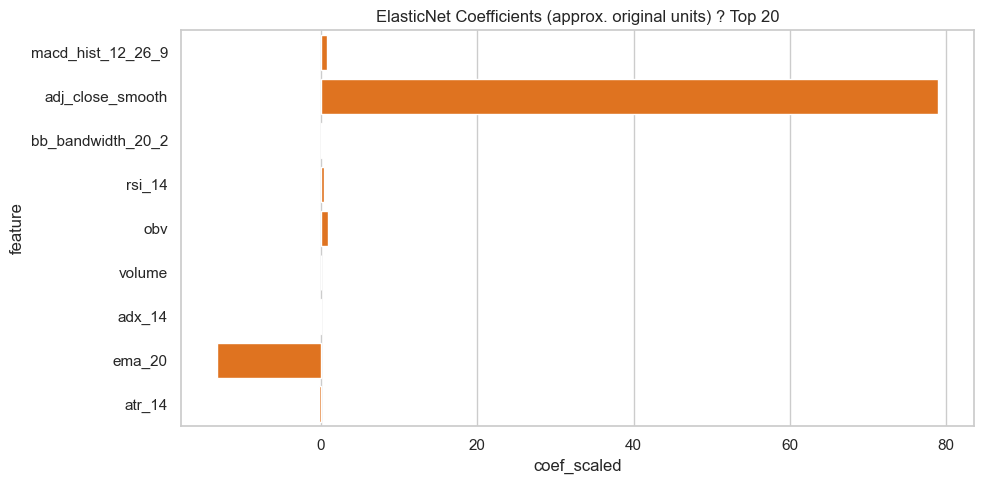

,feature,coef_scaled,coef_original_units
0,macd_hist_12_26_9,0.731810,1.240787e+00
1,adj_close_smooth,78.963713,1.190623e+00
2,bb_bandwidth_20_2,0.149133,3.220022e-02
3,rsi_14,0.369003,1.326629e-02
4,obv,0.913777,6.241746e-11
5,volume,0.001102,2.545467e-11
6,adx_14,-0.137631,-6.978048e-03
7,ema_20,-13.307496,-2.013344e-01
8,atr_14,-0.256846,-2.456155e-01


In [ ]:
# Coefficients
scaler = best_enet_pipe.named_steps["scaler"]
enet = best_enet_pipe.named_steps["enet"]

# Coefficients are learned on standardized features; convert to original feature units for readability
coef_scaled = enet.coef_.ravel()
coef_original_units = coef_scaled / scaler.scale_

coef_df = (
    pd.DataFrame(
        {
            "feature": feature_cols,
            "coef_scaled": coef_scaled,
            "coef_original_units": coef_original_units,
        }
    )
    .sort_values("coef_original_units", ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(10, 5))
sns.barplot(data=coef_df.head(20), x="coef_original_units", y="feature", color="#FF6F00")
plt.title("ElasticNet Coefficients (approx. original units) ? Top 20")
plt.tight_layout()
plt.show()

coef_df
